In [1]:
from keras.datasets import mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

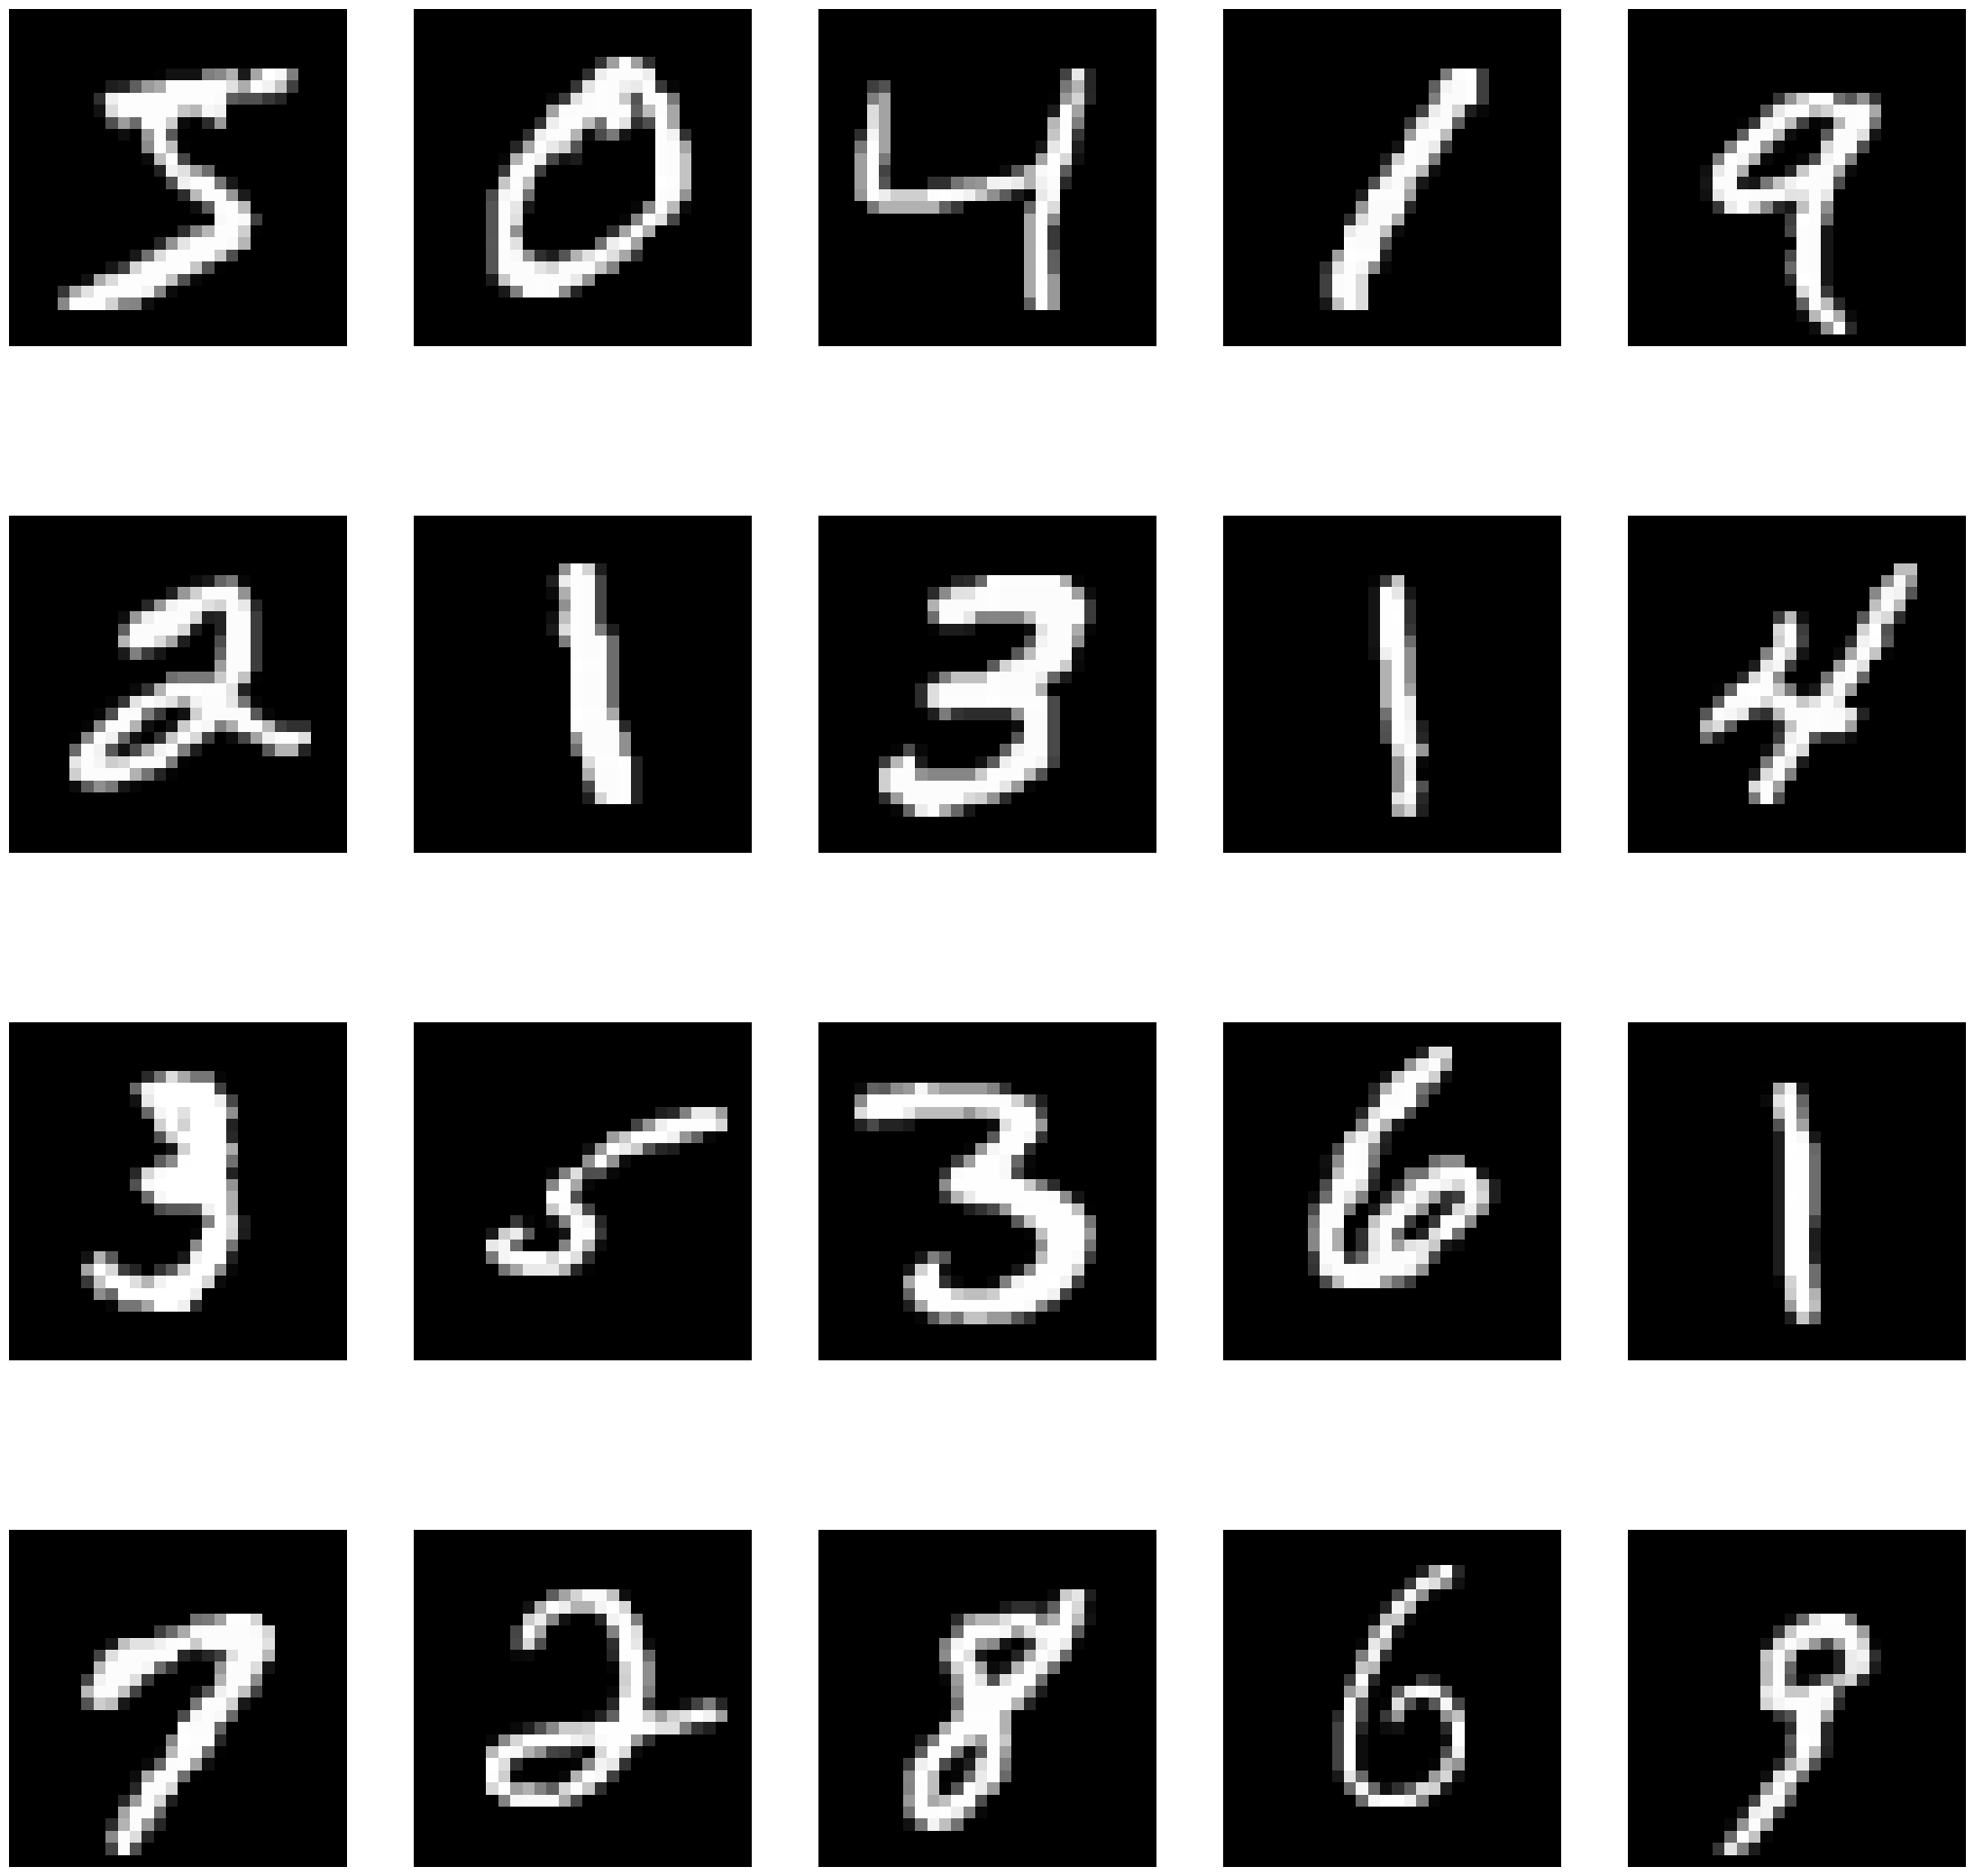

In [2]:
import pickle
import sys, os
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
sys.path.append(os.pardir)
#導入父目錄的文件


(x_train, t_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data(path= 'mnist.npz')

plt.figure(figsize=(28,28))
for i in range(20):
    plt.subplot(4,5,i+1)
    plt.imshow(x_train[i], cmap= "gray")
    plt.axis('off')

plt.show()

In [3]:
len(train_labels)

60000

In [4]:
train_labels

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [5]:
test_images.shape

(10000, 28, 28)

In [6]:
len(test_labels)

10000

In [7]:
test_labels

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

In [8]:
import tensorflow as tf
import keras
from keras import layers
model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10,activation="softmax")
])

In [9]:
model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [10]:
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype("float32") / 255

In [11]:
model.fit(train_images,train_labels,epochs=5,batch_size=128)

Epoch 1/5


469/469 [==============================] - 5s 8ms/step - loss: 0.2630 - accuracy: 0.9246
Epoch 2/5
469/469 [==============================] - 6s 12ms/step - loss: 0.1065 - accuracy: 0.9693
Epoch 3/5
469/469 [==============================] - 7s 14ms/step - loss: 0.0703 - accuracy: 0.9794
Epoch 4/5
469/469 [==============================] - 7s 14ms/step - loss: 0.0506 - accuracy: 0.9848
Epoch 5/5
469/469 [==============================] - 6s 13ms/step - loss: 0.0384 - accuracy: 0.9885


In [12]:
test_digits = test_images[0:10]
predictions = model.predict(test_digits)
predictions[0]

1/1 [==============================] - 0s 304ms/step


array([1.4407732e-07, 5.9958730e-08, 9.9745521e-06, 1.6840181e-04,
       1.0710783e-10, 2.9476871e-08, 1.3728427e-12, 9.9981946e-01,
       3.1700117e-07, 1.6348356e-06], dtype=float32)

In [13]:
predictions[0].argmax()

7

In [14]:
predictions[0][7]

0.99981946

In [15]:
test_labels[0]

7

In [16]:
test_loss,test_acc = model.evaluate(test_images, test_labels)

313/313 [==============================] - 3s 7ms/step - loss: 0.0656 - accuracy: 0.9786


In [17]:
print(f"test_acc:{test_acc}")

test_acc:0.978600025177002


In [18]:
import numpy as np

x=np.array(12)
x

array(12)

In [19]:
x.ndim

0

In [20]:
x =np.array([12,3,6,14,7])
x

array([12,  3,  6, 14,  7])

In [21]:
x.ndim

1

In [22]:
x = np.array([[5,78,2,34,0],
             [6,79,3,35,1],
             [7,80,4,36,2]])

In [23]:
x.ndim

2

In [24]:
x=np.array([[[5,78,2,34,0],
             [6,79,3,35,1],
             [7,80,4,36,2]],
            [[5,78,2,34,0],
             [6,79,3,35,1],
             [7,80,4,36,2]],
            [[5,78,2,34,0],
             [6,79,3,35,1],
             [7,80,4,36,2]]])

In [25]:
x.ndim

3

In [26]:
from keras.datasets import mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

In [27]:
train_images.ndim

3

In [28]:
train_images.shape

(60000, 28, 28)

In [29]:
train_images.dtype

dtype('uint8')

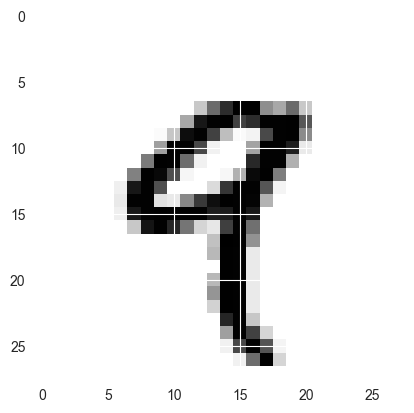

9

In [30]:
import matplotlib.pyplot as plt
digit = train_images[4]
plt.imshow(digit, cmap=plt.cm.binary)
plt.show()
train_labels[4]

In [31]:
my_slice = train_images[10:100]
my_slice.shape

(90, 28, 28)

In [32]:
my_slice = train_images[10:100, 0:28, 0:28]
my_slice.shape

(90, 28, 28)

In [33]:
my_slice = train_images[:, 14:, 14:]
my_slice =train_images[:,7:-7, 7:-7]
batch = train_images[:128]
batch= train_images[128:256]
n = 3
batch =train_images[128 * n:128 * (n + 1)]
keras.layers.Dense(512, activation="relu")

In [34]:
def naive_relu(x):
  assert len(x.shape) == 2
  x = x.copy()
  for i in range(x.shape[0]):
    for j in range(x.shape[1]):
      x[i,j] += y[i,j]

  return x

In [35]:
def naive_add(x,y):
  assert len(x.shape) == 2
  assert x.shape == y.shape
  x = x.copy()
  for i in range(x.shape[0]):
    for j in range(x.shape[1]):
      x[i,j] += y[i,j]
  return x

In [36]:
import time

x = np.random.random((20, 100))
y = np.random.random((20, 100))

t0 = time.time()
for _ in range(1000):
  z = x + y
  z = np.maximum(z, 0)
print("Took:{0: .2f}s".format(time.time() - t0))

Took: 0.03s


In [37]:
import time

x = np.random.random((20, 100))
y = np.random.random((20, 100))

t0 = time.time()
for _ in range(1000):
  z = naive_add(x, y)
  z = naive_relu(z)
print("Took:{0: .2f}s".format(time.time() - t0))

Took: 4.99s


In [38]:
import numpy as np
X = np.random.random((32,10))
y = np.random.random((10,))

In [39]:
y = np.expand_dims(y, axis=0)

In [40]:
Y = np.concatenate([y] * 32, axis=0)

In [41]:
def naive_add_matrix_and_vector(x,y):
  assert len(x.shape) == 2
  assert len(y.shape) == 1
  assert x.shape[1] == y.shape[0]
  x = x.copy()
  for i in range(x.shape[0]):
    for j in range(x.shape[1]):
      x[i,j] += y[j]
  return x

In [42]:
import numpy as np
x = np.random.random((64,3,32,10))
y = np.random.random((32, 10))
z = np.maximum(x, y)

In [43]:
x = np.random.random((32,))
y = np.random.random((32,))
z = np.dot(x, y)
z = x * y

In [44]:
def naive_vector_dot(x,y):
  assert len(x.shape) == 1
  assert len(y.shape) == 1
  assert x.shape[0] == y.shape[0]
  z = 0
  for i in range(x.shape[0]):
    z += x[i] * y[i]
  return z

In [45]:
def naive_matrix_dot(x, y):
  assert len(x.shape) == 2
  assert len(y.shape) == 2
  assert x.shape[1] == y.shape[0]
  z = np.zeros((x.shape[0], y.shape[1]))
  for i in range(x.shape[0]):
    for j in range(y.shape[1]):
      row_x = x[i, :]
      column_y = y[:, j]
      z[i, j] = naive_vector_dot(row_x, column_y)
  return z

In [46]:
train_images = train_images.reshape((60000, 28 * 28))

In [47]:
x = np.array([[0., 1.],
        [2., 3.],
        [4., 5.]])

In [48]:
x.shape

(3, 2)

In [49]:
x = x.reshape((6,1))

x

array([[0.],
       [1.],
       [2.],
       [3.],
       [4.],
       [5.]])

In [50]:
x = x.reshape((2,3))

x

array([[0., 1., 2.],
       [3., 4., 5.]])

In [51]:
x = np.zeros((300,20))
x = np.transpose(x)
x.shape

(20, 300)

In [52]:
A = [0.5, 1]

In [53]:
def fg(x):
  x1 = g(x)
  y = f(x1)
  return y

def fghj(x):
  x1 = j(x)
  x2 = h(x1)
  x3 = g(x2)
  y = f(x3)
  return y

In [54]:
import tensorflow as tf
x = tf.Variable(0.)
with tf.GradientTape() as tape:
  y = 2 * x + 3
grad_of_y_wrt_x = tape.gradient(y, x)
x = tf.Variable(tf.zeros((2, 2)))
with tf.GradientTape() as tape:
  y = 2 * x + 3
grad_of_y_wrt_x = tape.gradient(y, x)


In [55]:
W = tf.Variable(tf.random.uniform((2, 2)))
b = tf.Variable(tf.zeros(2,))
x = tf.random.uniform((2,2))
with tf.GradientTape() as tape:
  y = tf.matmul(x, W) + b
grad_of_y_wrt_W_and_b = tape.gradient(y, [W, b])

In [56]:
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10000 , 28 * 28))
test_images = test_images.astype("float32") / 255

In [57]:
model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])

In [58]:
model.compile(optimizer="rmsprop",
       loss= "sparse_categorical_crossentropy",
       metrics=["accuracy"])

In [59]:
model.fit(train_images,train_labels,epochs=5,batch_size=128)

Epoch 1/5
469/469 [==============================] - 8s 14ms/step - loss: 0.2613 - accuracy: 0.9246
Epoch 2/5
469/469 [==============================] - 6s 14ms/step - loss: 0.1059 - accuracy: 0.9685
Epoch 3/5
469/469 [==============================] - 6s 13ms/step - loss: 0.0687 - accuracy: 0.9797
Epoch 4/5
469/469 [==============================] - 6s 14ms/step - loss: 0.0502 - accuracy: 0.9847
Epoch 5/5
469/469 [==============================] - 6s 13ms/step - loss: 0.0381 - accuracy: 0.9889


In [60]:
import tensorflow as tf

class NaiveDense:
  def __init__ (self, input_size, output_size, activation):
    self.activation = activation
    w_shape = (input_size,output_size)
    w_initial_value = tf.random.uniform(w_shape, minval=0, maxval=1e-1)
    self.W = tf.Variable(w_initial_value)

    b_shape = (output_size,)
    b_initial_value = tf.zeros(b_shape)
    self.b = tf.Variable(b_initial_value)

  def __call__(self, inputs):
    return self.activation(tf.matmul(inputs, self.W) + self.b)

  @property
  def weights(self):
    return [self.W, self.b]

class NaiveSequential:

  def __init__(self, layers):
    self.layers = layers

  def __call__(self, inputs):
    x = inputs
    for layer in self.layers:
      x = layer(x)
    return x

  @property
  def weights(self):
    weights = []
    for layer in self.layers:
      weights += layer.weights
    return weights


model = NaiveSequential([
    NaiveDense(input_size=28 * 28, output_size=512, activation=tf.nn.relu),
    NaiveDense(input_size=512, output_size=10, activation=tf.nn.softmax)
])
assert len(model.weights) == 4

In [61]:
import math

class BatchGenerator:
  def __init__(self, images, labels, batch_size=128):
    assert len(images) == len(labels)
    self.index = 0
    self.images = images
    self.labels = labels
    self.batch_size = batch_size
    self.num_batches = math.ceil(len(images) / batch_size)

  def next(self):
    images = self.images[self.index : self.index + self.batch_size]
    labels = self.labels[self.index : self.index + self.batch_size]
    self.index += self.batch_size
    return images, labels

def one_training_step(model, images_batch, labels_batch):
  with tf.GradientTape() as tape:
    predictions = model(images_batch)
    per_sample_losses = tf.keras.losses.sparse_categorical_crossentropy(
        labels_batch, predictions
    )
    average_loss = tf.reduce_mean(per_sample_losses)
  gradients = tape.gradient(average_loss, model.weights)
  update_weights(gradients, model.weights)
  return average_loss

learning_rate = 1e-3

def update_weights(gradients, weights):
  for g, w in zip(gradients, weights):
    w.assign_sub(g * learning_rate)

In [62]:
from keras import optimizers

optimizer = optimizers.SGD(learning_rate = 1e-3)

def update_weights(gradients, weights):
  optimizer.apply_gradients(zip(gradients, weights))

In [63]:
def fit(model, images, labels, epochs, batch_size = 128):
  for epoch_counter in range(epochs):
    print(f"Epoch {epoch_counter}")
    data_generator = BatchGenerator(images, labels)
    for batch_counter in range(data_generator.num_batches):
      images_batch, labels_batch = data_generator.next()
      loss =  one_training_step(model, images_batch, labels_batch)
      if batch_counter % 100 == 0:
        print(f"loss at batch {batch_counter}: {loss: .2f}")

In [64]:
from keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

train_images = train_images.reshape((60000,28 * 28))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype("float32") / 255

fit(model, train_images, train_labels, epochs=10, batch_size=128)

Epoch 0
loss at batch 0:  6.29
loss at batch 100:  2.23
loss at batch 200:  2.21
loss at batch 300:  2.07
loss at batch 400:  2.22
Epoch 1
loss at batch 0:  1.91
loss at batch 100:  1.88
loss at batch 200:  1.83
loss at batch 300:  1.69
loss at batch 400:  1.84
Epoch 2
loss at batch 0:  1.59
loss at batch 100:  1.59
loss at batch 200:  1.51
loss at batch 300:  1.42
loss at batch 400:  1.53
Epoch 3
loss at batch 0:  1.34
loss at batch 100:  1.35
loss at batch 200:  1.24
loss at batch 300:  1.20
loss at batch 400:  1.30
Epoch 4
loss at batch 0:  1.14
loss at batch 100:  1.17
loss at batch 200:  1.05
loss at batch 300:  1.05
loss at batch 400:  1.13
Epoch 5
loss at batch 0:  1.00
loss at batch 100:  1.03
loss at batch 200:  0.91
loss at batch 300:  0.93
loss at batch 400:  1.01
Epoch 6
loss at batch 0:  0.89
loss at batch 100:  0.92
loss at batch 200:  0.80
loss at batch 300:  0.84
loss at batch 400:  0.92
Epoch 7
loss at batch 0:  0.80
loss at batch 100:  0.84
loss at batch 200:  0.72
lo

In [65]:
predictions = model(test_images)
predictions = predictions.numpy()
predicted_labels = np.argmax(predictions, axis=1)
matches = predicted_labels == test_labels
print(f"accuracy:{matches.mean():.2f}")

accuracy:0.82
